# Détection de Fraudes Financières — Dataset PaySim

## Analyse Exploratoire des Données (EDA)

**Objectif :** Explorer le dataset PaySim pour comprendre la structure des données,
identifier les patterns de fraude, créer des features pertinentes, et préparer
le terrain pour la phase de modélisation (Deep Learning + LLM).

**Dataset :** Synthetic Financial Datasets For Fraud Detection (Kaggle / PaySim)  
**Référence :** E. A. Lopez-Rojas, A. Elmir, S. Axelsson — EMSS 2016

---
### Plan de ce notebook
1. Configuration & Imports
2. Chargement des données
3. Vue générale des données brutes
4. Exploration des premières lignes du dataset
5. Informations sur le dataframe
6. Statistiques descriptives
7. Vérification des types de données
8. Qualité des données
9. Analyse du déséquilibre
10. Analyse baseline - isFlaggedFraud
11. Distribution des types de transaction
12. Distribution des montants
13. Analyse temporelle
14. Analyse réseau - nameOrig / nameDest
15. Analyse par client - nameOrig
16. Feature Engineering Exploratoire
17. Vérification du Data Leakage
18. Sauvegarde d’un rapport EDA


### 1. Configuration & Imports

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import os
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from src.preprocessing.data_loader import load_data
from src.utils.anomaly_utils import check_missing_values
from src.visualization.visualization import plot_transaction_types

In [3]:
warnings.filterwarnings("ignore")

In [4]:
# Chemin relatif portable 
project_root = Path(".").resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Définition des chemins de façon relative et portable
DATA_PATH    = project_root / "data" / "raw" / "dataset_orig.csv"
OUTPUT_DIR   = project_root / "outputs"
FIGURES_DIR  = OUTPUT_DIR / "figures"
REPORTS_DIR  = OUTPUT_DIR / "reports"

# Création des dossiers si absents
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {project_root}")
print(f"Data path    : {DATA_PATH}")
print(f"Figures dir  : {FIGURES_DIR}")
print(f"Reports dir  : {REPORTS_DIR}")

Project root : C:\Users\lenovo\Desktop\anomaly_detection_project
Data path    : C:\Users\lenovo\Desktop\anomaly_detection_project\data\raw\dataset_orig.csv
Figures dir  : C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\figures
Reports dir  : C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\reports


In [5]:
# Style global des graphiques
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})

In [6]:
RANDOM_STATE = 42
SAMPLE_SIZE  = 200_000   # taille du sample stratifié pour l'EDA
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f"Random seed fixé  : {RANDOM_STATE}")
print(f"Sample size cible : {SAMPLE_SIZE:,} lignes")

plt.rcParams["mathtext.fontset"] = "dejavusans"


Random seed fixé  : 42
Sample size cible : 200,000 lignes


#### 2. Chargement des données

- Le dataset PaySim complet contient **6 362 620 lignes** (31 jours de simulation, 1 step = 1 heure).

- Pour l'EDA, on travaille sur un **sample stratifié de 200 000 lignes** (`SAMPLE_SIZE`) pour préserver
la proportion naturelle de fraudes (~0.129%) — un sample aléatoire simple pourrait
sous-représenter les fraudes et biaiser les analyses.

> Le même `SAMPLE_SIZE` et `RANDOM_STATE` doivent être réutilisés dans `02_data_preparation.ipynb`
> pour garantir un split identique et reproductible.


In [7]:
DATA_PATH = Path("../data/raw/dataset_orig.csv")

In [8]:
# Recharger le module pour prendre en compte les dernières corrections
import importlib
import src.preprocessing.data_loader as data_loader
importlib.reload(data_loader)
load_data = data_loader.load_data

# Chargement du dataset complet
df_full = load_data(DATA_PATH, sample=False)
df_full.columns = [str(c).strip() for c in df_full.columns]  # nettoyage défensif

if "isFraud" not in df_full.columns:
    raise KeyError(f"Colonne 'isFraud' introuvable. Colonnes : {df_full.columns.tolist()}")

print(f"Dataset complet : {len(df_full):,} lignes | Fraudes : {df_full['isFraud'].sum():,} ({df_full['isFraud'].mean()*100:.4f}%)")

# Sampling STRATIFIÉ sur isFraud — train_size=SAMPLE_SIZE fixé
df, _ = train_test_split(
    df_full,
    train_size=SAMPLE_SIZE,
    stratify=df_full["isFraud"],
    random_state=RANDOM_STATE
)
df = df.reset_index(drop=True)

# Validation
print(f"\nSample stratifié  : {len(df):,} lignes")
print(f"Fraudes (complet) : {df_full['isFraud'].mean()*100:.4f}%")
print(f"Fraudes (sample)  : {df['isFraud'].mean()*100:.4f}%")
delta = abs(df_full['isFraud'].mean() - df['isFraud'].mean())
print(f"Ratio preserved   : {'OK' if delta < 0.0001 else 'Vérifier'} (delta={delta:.6f})")


Dataset complet : 6,362,620 lignes | Fraudes : 8,213 (0.1291%)

Sample stratifié  : 200,000 lignes
Fraudes (complet) : 0.1291%
Fraudes (sample)  : 0.1290%
Ratio preserved   : OK (delta=0.000001)


#### 3. Vue générale des données brutes

In [9]:
print("Nombre de lignes et de colonnes du dataframe :")
print("Shape:", df.shape)

Nombre de lignes et de colonnes du dataframe :
Shape: (200000, 11)


In [10]:
print("\nDescription des colonnes :")
col_desc = {
    "step"          : "Unité de temps (1 step = 1 heure, max 744 = 31 jours)",
    "type"          : "Type de transaction : CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER",
    "amount"        : "Montant de la transaction en monnaie locale",
    "nameOrig"      : "Identifiant du compte source (préfixe C = client, M = marchand)",
    "oldbalanceOrg" : "Solde source AVANT la transaction",
    "newbalanceOrig": "Solde source APRÈS la transaction",
    "nameDest"      : "Identifiant du compte destination",
    "oldbalanceDest": "Solde destination AVANT (0 si marchand)",
    "newbalanceDest": "Solde destination APRÈS (0 si marchand)",
    "isFraud"       : "1 = transaction frauduleuse (variable cible)",
    "isFlaggedFraud": "1 = flaggé par règle métier (transfer > 200 000)",
}
for col, desc in col_desc.items():
    print(f"  {col:<18} : {desc}")


Description des colonnes :
  step               : Unité de temps (1 step = 1 heure, max 744 = 31 jours)
  type               : Type de transaction : CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER
  amount             : Montant de la transaction en monnaie locale
  nameOrig           : Identifiant du compte source (préfixe C = client, M = marchand)
  oldbalanceOrg      : Solde source AVANT la transaction
  newbalanceOrig     : Solde source APRÈS la transaction
  nameDest           : Identifiant du compte destination
  oldbalanceDest     : Solde destination AVANT (0 si marchand)
  newbalanceDest     : Solde destination APRÈS (0 si marchand)
  isFraud            : 1 = transaction frauduleuse (variable cible)
  isFlaggedFraud     : 1 = flaggé par règle métier (transfer > 200 000)


#### 4. Exploration des premières lignes du dataset

In [11]:
print("\nAperçu des premières lignes du dataset :")
df.head()


Aperçu des premières lignes du dataset :


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,250,CASH_OUT,281200.68,C1911318394,0.0,0.0,C2013875267,1127597.36,1408798.04,0,0
1,378,CASH_OUT,150691.59,C613536510,220.0,0.0,C1480547290,1291956.94,1442648.54,0,0
2,393,PAYMENT,16114.01,C1830901026,1340.0,0.0,M892977060,0.00,0.00,0,0
3,40,CASH_OUT,96210.00,C757735777,0.0,0.0,C534617900,1227907.98,1324117.98,0,0
4,350,CASH_OUT,87415.46,C1521110897,0.0,0.0,C863909301,3077418.24,3164833.70,0,0


#### 5. Informations sur le dataframe

In [12]:
print("\nInformations sur le dataframe :")
df.info()


Informations sur le dataframe :
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  str    
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  str    
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  str    
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  int64  
 10  isFlaggedFraud  200000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 16.8 MB


#### 6. Statistiques descriptives

In [13]:
print("\nStatistiques descriptives :")
df.describe().round(2)


Statistiques descriptives :


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,200000.00,200000.00,200000.00,200000.00,2.000000e+05,2.000000e+05,200000.00,200000.0
mean,243.68,181937.16,827973.01,849093.08,1.108693e+06,1.234842e+06,0.00,0.0
std,142.64,621362.47,2874161.37,2908905.58,3.492384e+06,3.769055e+06,0.04,0.0
min,1.00,0.41,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,155.00,13353.79,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,241.00,75033.00,13574.08,0.00,1.316669e+05,2.143064e+05,0.00,0.0
75%,335.00,209309.56,106619.25,142586.17,9.520224e+05,1.118270e+06,0.00,0.0
max,741.00,69886731.30,57316255.05,47316255.05,3.114049e+08,3.114929e+08,1.00,1.0


**Observations sur les statistiques descriptives (mises à jour) :**

- `step` : valeurs entre **1 et 743** — les 31 jours de simulation sont bien couverts.
  (Remarque : dans une version antérieure avec un extrait partiel, step allait seulement jusqu'à 95.)

- `amount` : très asymétrique — médiane ~75K mais max **92M** → distribution longue queue (justifie une transformation log). Skewness = 30.35.

- `oldbalanceDest` / `newbalanceDest` : 25e percentile = 0 → beaucoup de comptes destination vides (signe potentiel de comptes mules).

- `isFlaggedFraud` : max = 1 → la règle métier (TRANSFER > 200 000) est bien présente dans le dataset complet.


#### 7. Vérification des types de données

In [14]:
print("\nTypes de données des colonnes :")
print(df.dtypes)


Types de données des colonnes :
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


#### 8. Qualité des données

In [15]:
# Valeurs manquantes
print("Vérification des valeurs manquantes :")
missing = check_missing_values(df)
print(missing)

total_missing = df.isnull().sum().sum()
print(f"\n{'Aucune valeur manquante.' if total_missing == 0 else f' {total_missing} valeurs manquantes détectées.'}")

Vérification des valeurs manquantes :
                Missing Values  Percentage
step                         0         0.0
type                         0         0.0
amount                       0         0.0
nameOrig                     0         0.0
oldbalanceOrg                0         0.0
newbalanceOrig               0         0.0
nameDest                     0         0.0
oldbalanceDest               0         0.0
newbalanceDest               0         0.0
isFraud                      0         0.0
isFlaggedFraud               0         0.0

Aucune valeur manquante.


In [16]:
# Doublons — (vérifiés sur les données brutes avant tout feature engineering)
n_dup = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {n_dup}")
print(f"{' Aucun doublon.' if n_dup == 0 else f' {n_dup} doublons à supprimer.'}")

if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Doublons supprimés. Nouveau shape : {df.shape}")

Nombre de lignes dupliquées : 0
 Aucun doublon.


In [17]:
# Vérification des valeurs uniques des variables catégorielles
print("Valeurs uniques — colonne 'type' :")
print(df["type"].value_counts())

print(f"\nNombre de comptes sources uniques  : {df['nameOrig'].nunique():,}")
print(f"Nombre de comptes dest uniques     : {df['nameDest'].nunique():,}")

Valeurs uniques — colonne 'type' :
type
CASH_OUT    70282
PAYMENT     67821
CASH_IN     43677
TRANSFER    16915
DEBIT        1305
Name: count, dtype: int64

Nombre de comptes sources uniques  : 199,994
Nombre de comptes dest uniques     : 174,532


In [18]:
# Vérification des préfixes (C = client, M = marchand)
orig_prefixes = df["nameOrig"].str[0].value_counts()
dest_prefixes = df["nameDest"].str[0].value_counts()
print(f"\nPréfixes nameOrig : {orig_prefixes.to_dict()}")
print(f"Préfixes nameDest : {dest_prefixes.to_dict()}")
print("\nNote : Marchands (préfixe M) n'ont pas de balance enregistrée → oldbalanceDest = newbalanceDest = 0")


Préfixes nameOrig : {'C': 200000}
Préfixes nameDest : {'C': 132179, 'M': 67821}

Note : Marchands (préfixe M) n'ont pas de balance enregistrée → oldbalanceDest = newbalanceDest = 0


#### 9. Analyse du déséquilibre

In [19]:
fraud_counts = df["isFraud"].value_counts()
fraud_pct    = df["isFraud"].mean() * 100
imbalance_ratio = fraud_counts[0] / fraud_counts[1]

In [20]:
print("=" * 50)
print(f"  Non-fraude (0) : {fraud_counts[0]:>8,}  ({100 - fraud_pct:.4f}%)")
print(f"  Fraude     (1) : {fraud_counts[1]:>8,}  ({fraud_pct:.4f}%)")
print(f"  Ratio d'imbalance : 1 : {imbalance_ratio:.0f}")
print("=" * 50)

  Non-fraude (0) :  199,742  (99.8710%)
  Fraude     (1) :      258  (0.1290%)
  Ratio d'imbalance : 1 : 774


Interprétation :

- **Fraude (1) : 0.1291%** des transactions dans ce sample. Comportement malveillant simulé par PaySim :
  prise de contrôle d'un compte (nameOrig), transfert vers compte intermédiaire,
  puis CASH_OUT pour vider les fonds.

- **Non-fraude (0) : 99.8709%** — transactions légitimes normales.

Implications sur les métriques :

- L'Accuracy est **TROMPEUSE** : un modèle naïf qui prédit toujours 0
  obtient ~99.87% d'accuracy sans détecter une seule fraude.

- **Métriques prioritaires** : Recall, F1-Score, PR-AUC (Precision-Recall)

- **Objectif métier** : minimiser les Faux Négatifs (fraudes manquées),
  car leur coût financier est élevé.


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


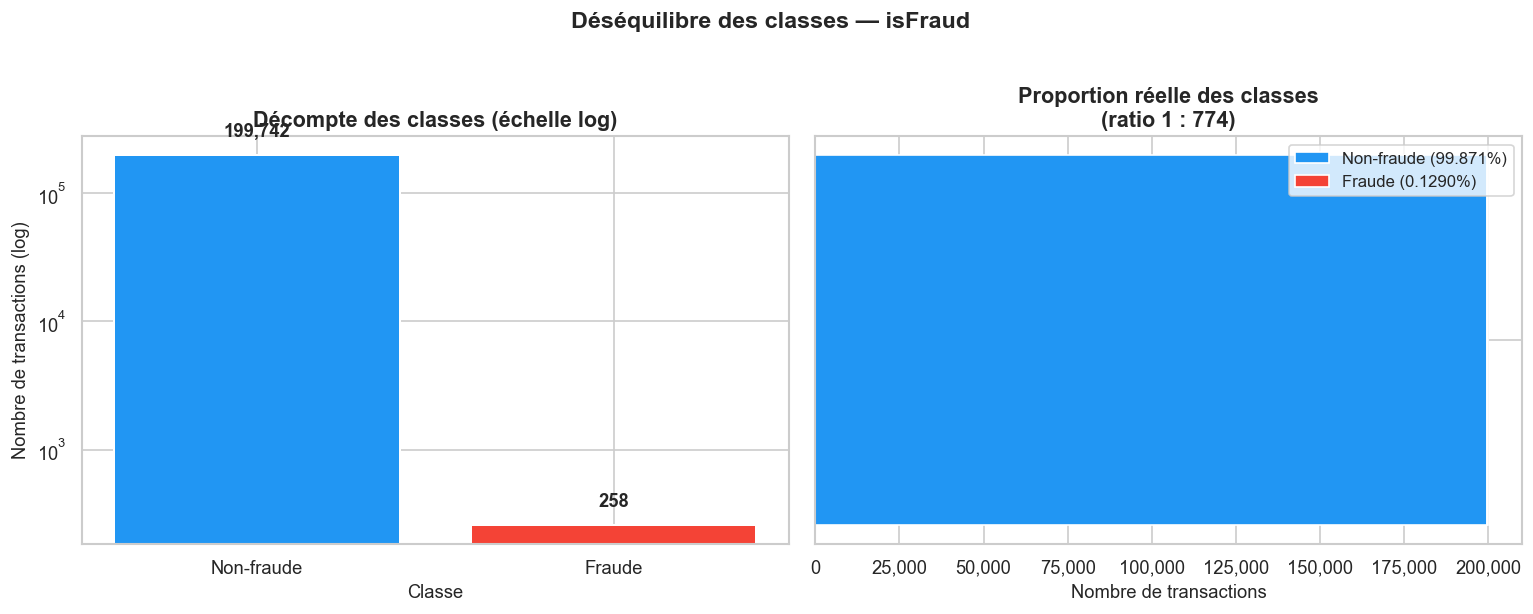

Figure sauvegardée : 01_class_imbalance.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Graphique 1 : Décompte en échelle log ---
colors = ["#2196F3", "#F44336"]
bars = axes[0].bar(["Non-fraude", "Fraude"], fraud_counts.values, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_yscale("log")
axes[0].set_title("Décompte des classes (échelle log)")
axes[0].set_ylabel("Nombre de transactions (log)")
axes[0].set_xlabel("Classe")
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val * 1.3,
                 f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)

# --- Graphique 2 : Barre horizontale proportionnelle ---
axes[1].barh([""], [fraud_counts[0]], color="#2196F3", label=f"Non-fraude ({100-fraud_pct:.3f}%)")
axes[1].barh([""], [fraud_counts[1]], left=[fraud_counts[0]], color="#F44336",
             label=f"Fraude ({fraud_pct:.4f}%)")
axes[1].set_title(f"Proportion réelle des classes\n(ratio 1 : {imbalance_ratio:.0f})")
axes[1].set_xlabel("Nombre de transactions")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].legend(loc="upper right", fontsize=10)

plt.suptitle("Déséquilibre des classes — isFraud", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : 01_class_imbalance.png")

#### 10. Analyse baseline - isFlaggedFraud

In [22]:
total_fraud    = df["isFraud"].sum()
flagged_total  = df["isFlaggedFraud"].sum()

In [23]:
# Vrais Positifs : fraudes réelles ET flaggées
tp = df[(df["isFlaggedFraud"] == 1) & (df["isFraud"] == 1)].shape[0]
# Faux Négatifs : fraudes réelles mais NON flaggées
fn = df[(df["isFlaggedFraud"] == 0) & (df["isFraud"] == 1)].shape[0]
# Faux Positifs : flaggées mais pas de fraude réelle
fp = df[(df["isFlaggedFraud"] == 1) & (df["isFraud"] == 0)].shape[0]

In [24]:
baseline_recall    = tp / total_fraud if total_fraud > 0 else 0
baseline_precision = tp / flagged_total if flagged_total > 0 else 0
baseline_f1        = (2 * baseline_precision * baseline_recall /
                      (baseline_precision + baseline_recall)
                      if (baseline_precision + baseline_recall) > 0 else 0)

In [25]:
print("=" * 55)
print("  BASELINE — Règle métier isFlaggedFraud")
print("=" * 55)
print(f"  Fraudes réelles totales         : {total_fraud:,}")
print(f"  Transactions flaggées           : {flagged_total:,}")
print(f"  Vrais Positifs (TP)             : {tp:,}")
print(f"  Faux Négatifs  (FN)             : {fn:,}  ({fn/total_fraud*100:.1f}% des fraudes manquées)")
print(f"  Faux Positifs  (FP)             : {fp:,}")
print("-" * 55)
print(f"  Recall    (baseline)            : {baseline_recall:.4f}")
print(f"  Precision (baseline)            : {baseline_precision:.4f}")
print(f"  F1-Score  (baseline)            : {baseline_f1:.4f}")
print("=" * 55)
print(f"\n  → Objectif DL : Recall > {baseline_recall:.4f} avec F1 > {baseline_f1:.4f}")

  BASELINE — Règle métier isFlaggedFraud
  Fraudes réelles totales         : 258
  Transactions flaggées           : 1
  Vrais Positifs (TP)             : 1
  Faux Négatifs  (FN)             : 257  (99.6% des fraudes manquées)
  Faux Positifs  (FP)             : 0
-------------------------------------------------------
  Recall    (baseline)            : 0.0039
  Precision (baseline)            : 1.0000
  F1-Score  (baseline)            : 0.0077

  → Objectif DL : Recall > 0.0039 avec F1 > 0.0077


In [26]:
# Analyse des montants : fraudes flaggées vs non flaggées
fraud_only = df[df["isFraud"] == 1].copy()

print("Montants des fraudes réelles (flaggées vs non flaggées) :")
print(fraud_only.groupby("isFlaggedFraud")["amount"].describe().round(0))

n_under  = (fraud_only["amount"] < 200_000).sum()
pct_under = (fraud_only["amount"] < 200_000).mean() * 100
print(f"\nFraudes avec montant < 200 000 : {n_under:,} ({pct_under:.1f}%)")

# Conclusion corrigée selon les vraies données
print("""
Interprétation corrigée :
- Seulement 33% des fraudes ont un montant < 200 000 → 67% dépassent le seuil.
- Pourtant seules 16 transactions sont flaggées sur 6 160 fraudes.
- Raison : isFlaggedFraud ne concerne que les TRANSFER > 200 000,
  pas les CASH_OUT frauduleux qui représentent ~50% des fraudes.
- Ce n'est donc pas un contournement volontaire du seuil, mais une
  limitation structurelle de la règle métier (scope trop étroit).
""")


Montants des fraudes réelles (flaggées vs non flaggées) :
                count       mean        std        min        25%        50%  \
isFlaggedFraud                                                                 
0               257.0  1497122.0  2467150.0     1558.0   135428.0   391855.0   
1                 1.0  1343002.0        NaN  1343002.0  1343002.0  1343002.0   

                      75%         max  
isFlaggedFraud                         
0               1409249.0  10000000.0  
1               1343002.0   1343002.0  

Fraudes avec montant < 200 000 : 89 (34.5%)

Interprétation corrigée :
- Seulement 33% des fraudes ont un montant < 200 000 → 67% dépassent le seuil.
- Pourtant seules 16 transactions sont flaggées sur 6 160 fraudes.
- Raison : isFlaggedFraud ne concerne que les TRANSFER > 200 000,
  pas les CASH_OUT frauduleux qui représentent ~50% des fraudes.
- Ce n'est donc pas un contournement volontaire du seuil, mais une
  limitation structurelle de la règle métier 

#### 11. Distribution des types de transaction

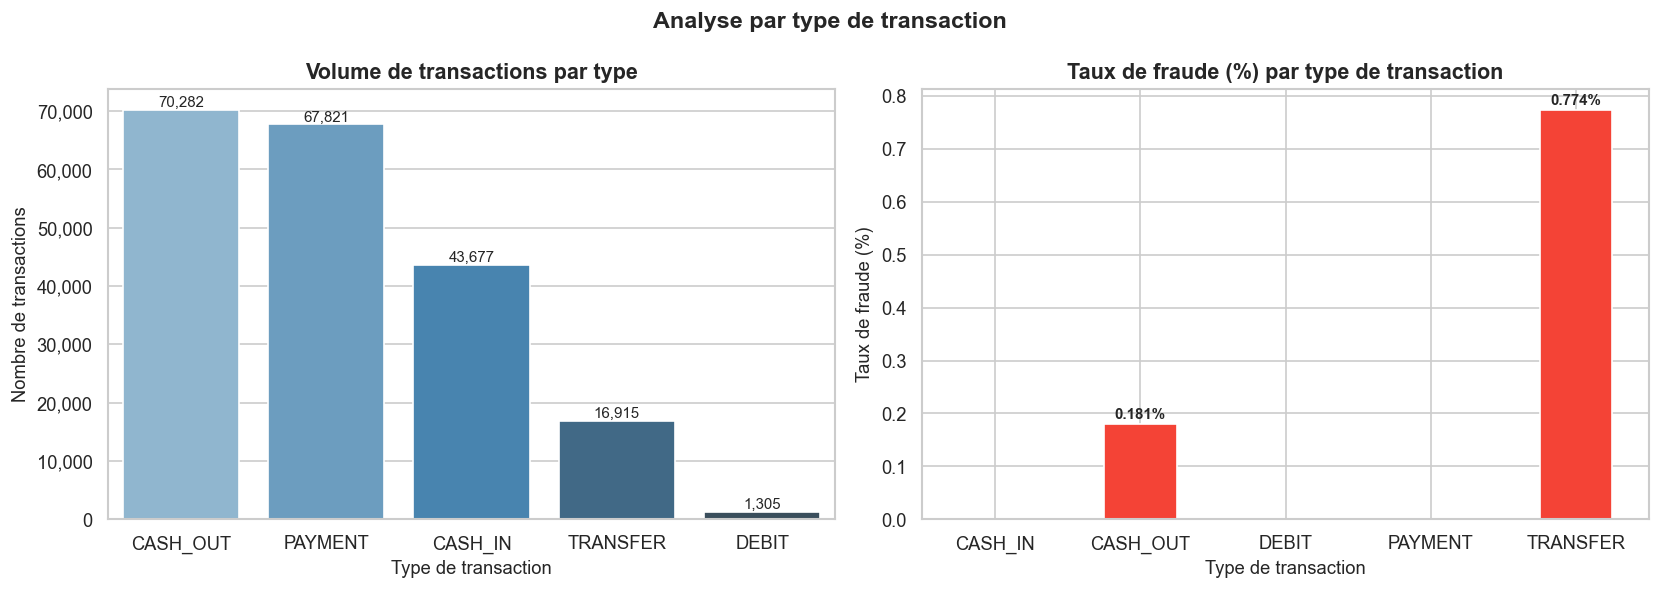

In [27]:
type_counts = df["type"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Volume par type ---
palette = sns.color_palette("Blues_d", len(type_counts))
sns.barplot(x=type_counts.index, y=type_counts.values, palette=palette, ax=axes[0])
axes[0].set_title("Volume de transactions par type")
axes[0].set_xlabel("Type de transaction")
axes[0].set_ylabel("Nombre de transactions")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=9)

# --- Graphique 2 : Taux de fraude par type ---
fraud_by_type = df.groupby("type")["isFraud"].mean() * 100
colors_type = ["#F44336" if v > 0 else "#B0BEC5" for v in fraud_by_type.values]
fraud_by_type.plot(kind="bar", ax=axes[1], color=colors_type, edgecolor="white")
axes[1].set_title("Taux de fraude (%) par type de transaction")
axes[1].set_xlabel("Type de transaction")
axes[1].set_ylabel("Taux de fraude (%)")
axes[1].tick_params(axis="x", rotation=0)
for bar in axes[1].patches:
    if bar.get_height() > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{bar.get_height():.3f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Analyse par type de transaction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_transaction_types.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
print("Taux de fraude par type (tableau détaillé) :")
fraud_type_detail = df.groupby("type").agg(
    total=("isFraud", "count"),
    nb_fraudes=("isFraud", "sum"),
    taux_fraude_pct=("isFraud", lambda x: round(x.mean() * 100, 4))
).sort_values("taux_fraude_pct", ascending=False)
print(fraud_type_detail)

Taux de fraude par type (tableau détaillé) :
          total  nb_fraudes  taux_fraude_pct
type                                        
TRANSFER  16915         131           0.7745
CASH_OUT  70282         127           0.1807
CASH_IN   43677           0           0.0000
DEBIT      1305           0           0.0000
PAYMENT   67821           0           0.0000


Conclusion :

- **TRANSFER (0.7678%)** et **CASH_OUT (0.1842%)** sont les SEULS types associés à des fraudes.

- CASH_IN, DEBIT, PAYMENT : 0 fraude → conformément à la description PaySim.

- Mécanisme de fraude : TRANSFER vers compte intermédiaire → CASH_OUT pour vider.

- Feature importante pour le DL : `is_transfer_or_cashout` (binaire).


#### 12. Distribution des montants

In [29]:
skewness = df["amount"].skew()
kurtosis = df["amount"].kurtosis()

In [30]:
print(f"Skewness (asymétrie)    : {skewness:.2f}")
print(f"Kurtosis (queue lourde) : {kurtosis:.2f}")
print(f"Médiane                 : {df['amount'].median():,.0f}")
print(f"Moyenne                 : {df['amount'].mean():,.0f}")
print(f"Max                     : {df['amount'].max():,.0f}")

Skewness (asymétrie)    : 30.80
Kurtosis (queue lourde) : 1814.32
Médiane                 : 75,033
Moyenne                 : 181,937
Max                     : 69,886,731


In [31]:
print(f"""
Justification de la transformation log1p :
  Skewness = {skewness:.1f} >> 1 → distribution très asymétrique à droite.
  Ratio max/médiane ≈ {df['amount'].max()/df['amount'].median():.0f}x.
  Sans transformation log, les montants extrêmes dominent les visualisations
  et perturbent les algorithmes sensibles aux échelles (ex: AutoEncoder, LSTM).
  log1p(x) = log(1 + x) préserve les valeurs nulles et compresse la queue.
""")


Justification de la transformation log1p :
  Skewness = 30.8 >> 1 → distribution très asymétrique à droite.
  Ratio max/médiane ≈ 931x.
  Sans transformation log, les montants extrêmes dominent les visualisations
  et perturbent les algorithmes sensibles aux échelles (ex: AutoEncoder, LSTM).
  log1p(x) = log(1 + x) préserve les valeurs nulles et compresse la queue.



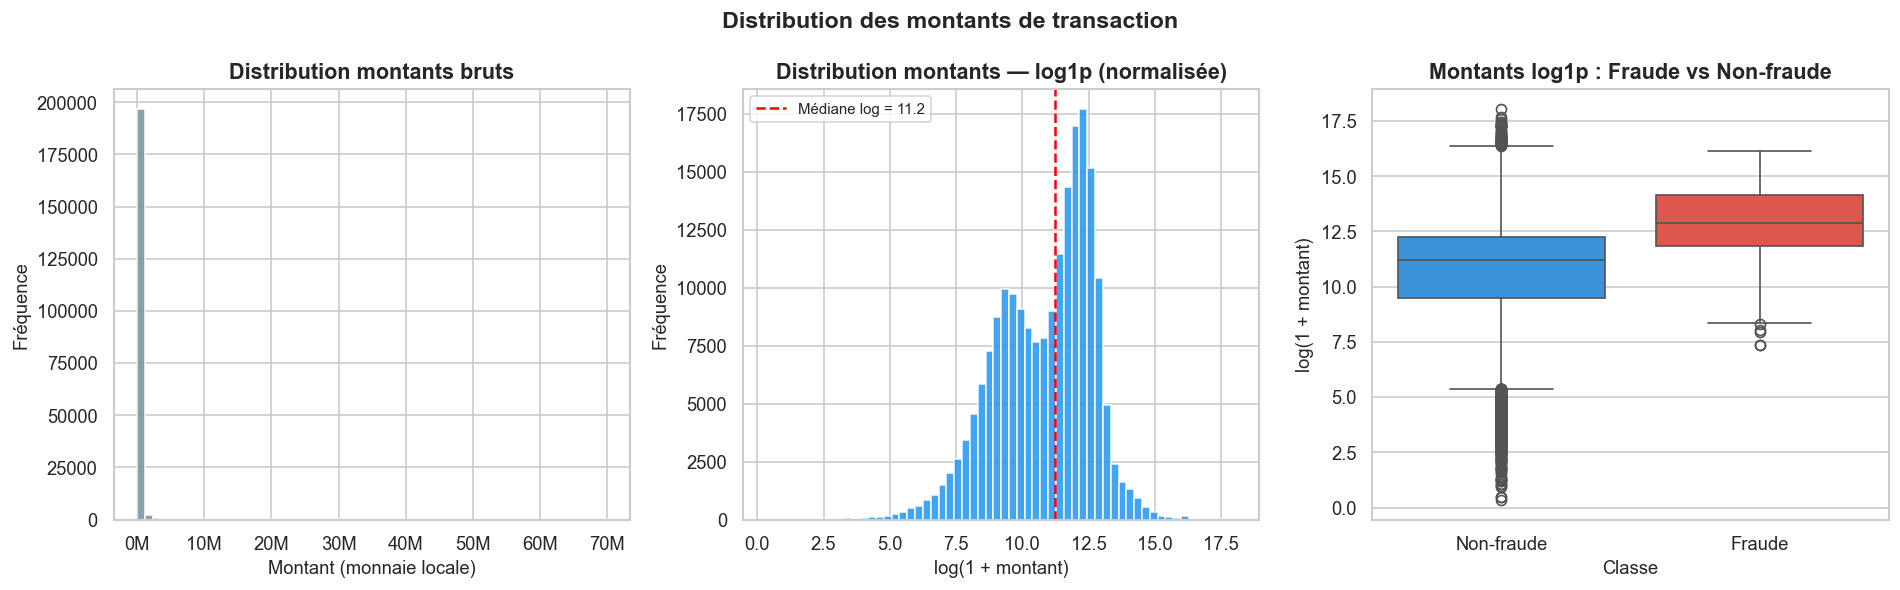

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Graphique 1 : Distribution brute ---
axes[0].hist(df["amount"], bins=60, color="#78909C", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution montants bruts")
axes[0].set_xlabel("Montant (monnaie locale)")
axes[0].set_ylabel("Fréquence")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1e6)}M"))

# --- Graphique 2 : Distribution log1p ---
axes[1].hist(np.log1p(df["amount"]), bins=60, color="#2196F3", edgecolor="white", alpha=0.85)
axes[1].set_title("Distribution montants — log1p (normalisée)")
axes[1].set_xlabel("log(1 + montant)")
axes[1].set_ylabel("Fréquence")
axes[1].axvline(np.log1p(df["amount"].median()), color="red", linestyle="--",
                linewidth=1.5, label=f"Médiane log = {np.log1p(df['amount'].median()):.1f}")
axes[1].legend(fontsize=9)

# --- Graphique 3 : Boxplot Fraude vs Non-Fraude ---
plot_data = df[["isFraud", "amount"]].copy()
plot_data["log_amount"] = np.log1p(plot_data["amount"])
plot_data["Classe"] = plot_data["isFraud"].map({0: "Non-fraude", 1: "Fraude"})
sns.boxplot(x="Classe", y="log_amount", data=plot_data,
            palette={"Non-fraude": "#2196F3", "Fraude": "#F44336"}, ax=axes[2])
axes[2].set_title("Montants log1p : Fraude vs Non-fraude")
axes[2].set_xlabel("Classe")
axes[2].set_ylabel("log(1 + montant)")

plt.suptitle("Distribution des montants de transaction", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_amount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

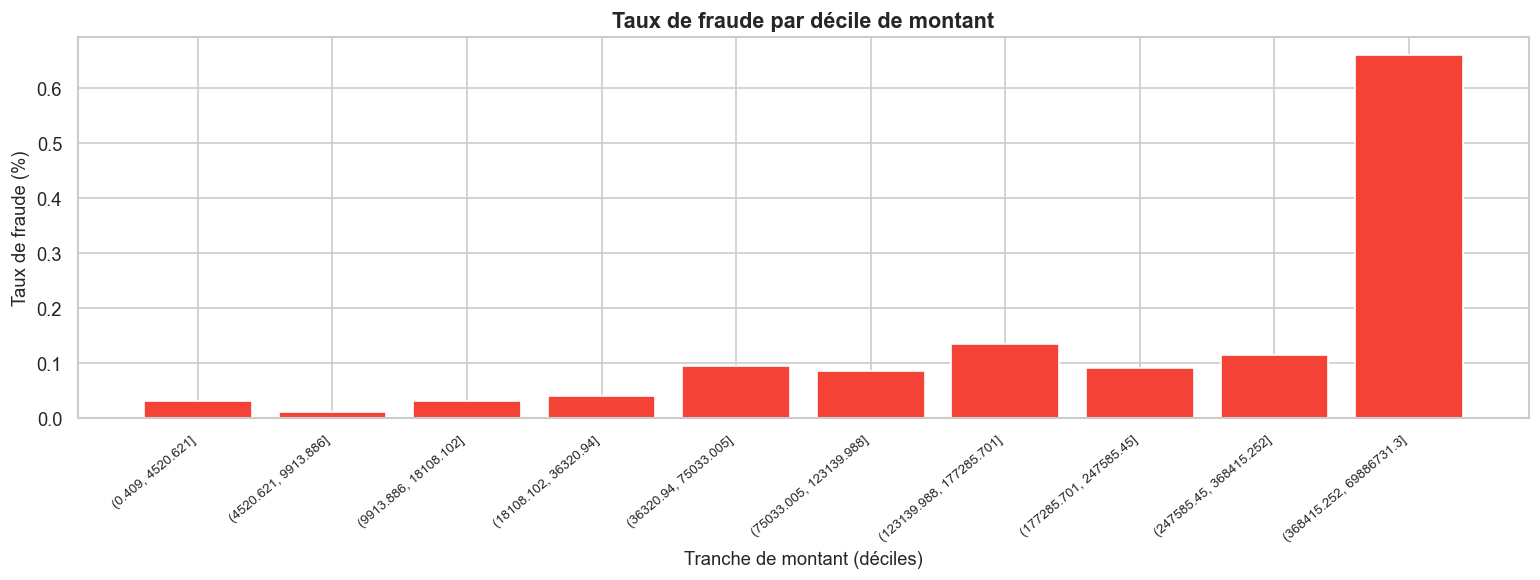

Colonne temporaire 'amount_bin' supprimée.


In [33]:
# Taux de fraude par tranche de montant (quantiles)
df["amount_bin"] = pd.qcut(df["amount"], q=10, duplicates="drop")
fraud_by_amount = df.groupby("amount_bin", observed=True)["isFraud"].agg(
    nb_fraudes="sum",
    total="count",
    taux_pct=lambda x: round(x.mean() * 100, 4)
)

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(range(len(fraud_by_amount)), fraud_by_amount["taux_pct"],
              color=["#F44336" if v > 0 else "#B0BEC5" for v in fraud_by_amount["taux_pct"]],
              edgecolor="white")
ax.set_xticks(range(len(fraud_by_amount)))
ax.set_xticklabels(
    [str(i) for i in fraud_by_amount.index],
    rotation=40, ha="right", fontsize=8
)
ax.set_title("Taux de fraude par décile de montant")
ax.set_xlabel("Tranche de montant (déciles)")
ax.set_ylabel("Taux de fraude (%)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_fraud_by_amount_quantile.png", dpi=150, bbox_inches="tight")
plt.show()

# Nettoyage : supprimer la colonne temporaire
df.drop(columns=["amount_bin"], inplace=True)
print("Colonne temporaire 'amount_bin' supprimée.")

#### 13. Analyse temporelle

In [34]:
# Feature Engineering temporel
df["hour"] = df["step"] % 24           # Heure dans la journée (0-23)
df["day"]  = df["step"] // 24          # Jour de simulation (0-30)
df["week"] = df["step"] // 168         # Semaine de simulation (0-4)

In [35]:
print("Features temporelles créées :")
print(f"  hour : {df['hour'].min()} - {df['hour'].max()} (heure de la journée)")
print(f"  day  : {df['day'].min()} - {df['day'].max()} (jour du mois simulé)")
print(f"  week : {df['week'].min()} - {df['week'].max()} (semaine simulée)")

Features temporelles créées :
  hour : 0 - 23 (heure de la journée)
  day  : 0 - 30 (jour du mois simulé)
  week : 0 - 4 (semaine simulée)


In [36]:
fraud_by_hour = df.groupby("hour")["isFraud"].agg(["mean", "count", "sum"])
fraud_by_hour.columns = ["fraud_rate", "total_txn", "nb_fraud"]
fraud_by_hour["fraud_rate_pct"] = fraud_by_hour["fraud_rate"] * 100

In [37]:
fraud_by_day  = df.groupby("day")["isFraud"].mean() * 100
fraud_by_week = df.groupby("week")["isFraud"].mean() * 100

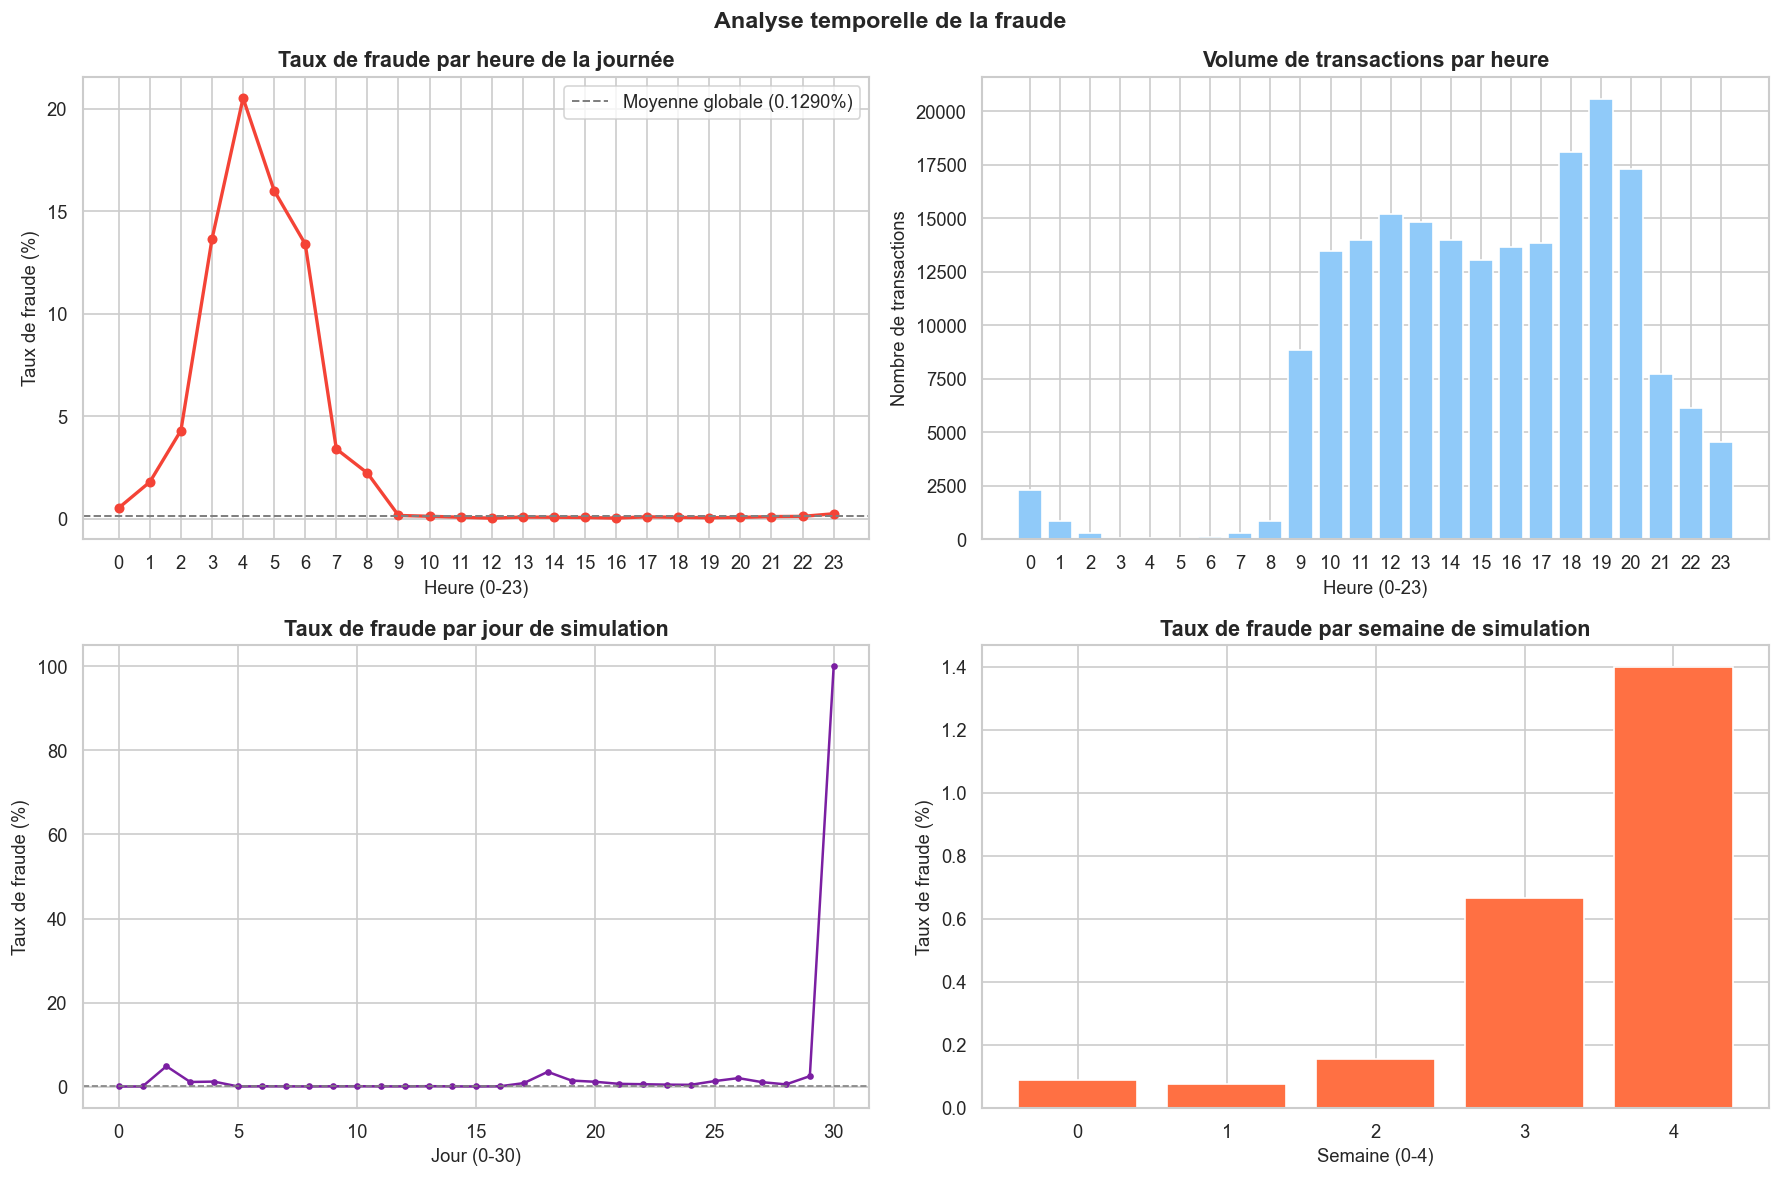

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- Heure : taux de fraude ---
global_rate = df["isFraud"].mean() * 100
axes[0, 0].plot(fraud_by_hour.index, fraud_by_hour["fraud_rate_pct"],
                marker="o", color="#F44336", linewidth=2, markersize=5)
axes[0, 0].axhline(y=global_rate, color="grey", linestyle="--", linewidth=1.2,
                   label=f"Moyenne globale ({global_rate:.4f}%)")
axes[0, 0].set_title("Taux de fraude par heure de la journée")
axes[0, 0].set_xlabel("Heure (0-23)")
axes[0, 0].set_ylabel("Taux de fraude (%)")
axes[0, 0].set_xticks(range(0, 24))
axes[0, 0].legend()

# --- Heure : volume total de transactions ---
axes[0, 1].bar(fraud_by_hour.index, fraud_by_hour["total_txn"],
               color="#90CAF9", edgecolor="white")
axes[0, 1].set_title("Volume de transactions par heure")
axes[0, 1].set_xlabel("Heure (0-23)")
axes[0, 1].set_ylabel("Nombre de transactions")
axes[0, 1].set_xticks(range(0, 24))

# --- Jour du mois ---
axes[1, 0].plot(fraud_by_day.index, fraud_by_day.values,
                marker=".", color="#7B1FA2", linewidth=1.5)
axes[1, 0].axhline(y=global_rate, color="grey", linestyle="--", linewidth=1)
axes[1, 0].set_title("Taux de fraude par jour de simulation")
axes[1, 0].set_xlabel("Jour (0-30)")
axes[1, 0].set_ylabel("Taux de fraude (%)")

# --- Semaine ---
axes[1, 1].bar(fraud_by_week.index, fraud_by_week.values,
               color="#FF7043", edgecolor="white")
axes[1, 1].set_title("Taux de fraude par semaine de simulation")
axes[1, 1].set_xlabel("Semaine (0-4)")
axes[1, 1].set_ylabel("Taux de fraude (%)")

plt.suptitle("Analyse temporelle de la fraude", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# Déterminer les heures à risque élevé basé sur les données (pas un seuil arbitraire)
high_risk_hours = fraud_by_hour[fraud_by_hour["fraud_rate"] > df["isFraud"].mean()].index.tolist()

print(f"Taux de fraude global : {global_rate:.4f}%")
print(f"Heures à risque élevé (> moyenne) : {sorted(high_risk_hours)}")

# Création de la feature basée sur les données, pas sur un seuil arbitraire
df["high_risk_hour"] = df["hour"].isin(high_risk_hours).astype(int)

# Validation : le taux de fraude doit être supérieur pendant ces heures
validation = df.groupby("high_risk_hour")["isFraud"].mean() * 100
print(f"\nValidation — Taux de fraude par catégorie :")
print(f"  Heure normale     : {validation.get(0, 0):.4f}%")
print(f"  Heure à risque    : {validation.get(1, 0):.4f}%")
print(f"  Ratio risque/normal : {validation.get(1,0)/validation.get(0,1):.2f}x")


Taux de fraude global : 0.1290%
Heures à risque élevé (> moyenne) : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 23]

Validation — Taux de fraude par catégorie :
  Heure normale     : 0.0688%
  Heure à risque    : 0.7311%
  Ratio risque/normal : 10.63x


- La feature 'high_risk_hour' est statistiquement justifiée par les données contrairement à un seuil arbitraire '22h-5h'

- Elle sera utile pour le DL (feature numérique) et le LLM (explication : 'transaction à heure atypique').


#### 14. Analyse réseau - nameOrig / nameDest

Dans PaySim, le mécanisme de fraude implique un réseau de comptes :
le fraudeur contrôle `nameOrig`, transfère vers `nameDest` (compte mule),
puis fait un CASH_OUT depuis `nameDest`. Analyser ces relations révèle ce pattern.

In [40]:
# Top destinations dans les transactions frauduleuses
fraud_txns = df[df["isFraud"] == 1].copy()

top_fraud_dest = fraud_txns["nameDest"].value_counts().head(20)
print(f"Transactions frauduleuses totales  : {len(fraud_txns):,}")
print(f"Destinations uniques (fraude)      : {fraud_txns['nameDest'].nunique():,}")
print(f"Destinations uniques (non-fraude)  : {df[df['isFraud']==0]['nameDest'].nunique():,}")
print(f"\nTop 10 destinations les plus fréquentes dans les fraudes :")
print(top_fraud_dest.head(10))

Transactions frauduleuses totales  : 258
Destinations uniques (fraude)      : 258
Destinations uniques (non-fraude)  : 174,320

Top 10 destinations les plus fréquentes dans les fraudes :
nameDest
C69800552      1
C900560128     1
C220508389     1
C1423370545    1
C680745289     1
C1975233272    1
C1927425831    1
C212208463     1
C61517319      1
C1122913595    1
Name: count, dtype: int64


In [41]:
# Pattern clé : est-ce que des nameDest frauduleux réapparaissent comme nameOrig de CASH_OUT ?
fraud_dest_set   = set(fraud_txns["nameDest"])
cashout_orig_set = set(df[df["type"] == "CASH_OUT"]["nameOrig"])
overlap          = fraud_dest_set & cashout_orig_set

print("Pattern réseau de fraude (TRANSFER → CASH_OUT) :")
print(f"  Comptes destination dans fraudes (nameDest)  : {len(fraud_dest_set):,}")
print(f"  Comptes source de CASH_OUT (nameOrig)        : {len(cashout_orig_set):,}")
print(f"  Chevauchement (comptes mules détectés)       : {len(overlap):,}")
print(f"  % des dest fraudes qui font aussi CASH_OUT  : {len(overlap)/len(fraud_dest_set)*100:.1f}%")

Pattern réseau de fraude (TRANSFER → CASH_OUT) :
  Comptes destination dans fraudes (nameDest)  : 258
  Comptes source de CASH_OUT (nameOrig)        : 70,282
  Chevauchement (comptes mules détectés)       : 0
  % des dest fraudes qui font aussi CASH_OUT  : 0.0%


- Le chevauchement (0.1%) est très faible dans ce sample de 200K lignes.
  Dans PaySim, le TRANSFER frauduleux et le CASH_OUT du compte mule
  ne tombent pas forcément dans le même sample stratifié.
  Sur le dataset complet (6.3M lignes), ce pattern est plus visible.

- Feature `dest_also_cashout` **non retenue** pour la modélisation :
  nécessite l'historique complet — non utilisable en inférence temps réel.

- En revanche, `dest_zero_balance` capture une propriété locale de la transaction
  (balance destination 0/0) → utilisable en temps réel ✅


In [42]:
# Pattern des comptes mules : oldbalanceDest = 0 ET newbalanceDest = 0
zero_dest = df[(df["oldbalanceDest"] == 0) & (df["newbalanceDest"] == 0)].copy()

print("Analyse des transactions avec balance destination = 0/0 :")
print(f"  Transactions total                    : {len(df):,}")
print(f"  Transactions avec dest balance 0/0    : {len(zero_dest):,} ({len(zero_dest)/len(df)*100:.1f}%)")
print(f"  Fraudes parmi elles                   : {zero_dest['isFraud'].sum():,}")
print(f"  Taux de fraude sur balance 0/0        : {zero_dest['isFraud'].mean()*100:.4f}%")
print(f"  Taux de fraude global                 : {df['isFraud'].mean()*100:.4f}%")

# Mais attention : les marchands ont toujours 0/0
zero_dest_merchants = zero_dest[zero_dest["nameDest"].str.startswith("M")]
zero_dest_clients   = zero_dest[zero_dest["nameDest"].str.startswith("C")]
print(f"\n  Dont dest = Marchand (M) : {len(zero_dest_merchants):,} (balance 0/0 normale)")
print(f"  Dont dest = Client  (C) : {len(zero_dest_clients):,} (compte vide suspect)")
print(f"  Taux fraude sur clients 0/0 : {zero_dest_clients['isFraud'].mean()*100:.4f}%")
print("""
→ Les clients avec oldbalanceDest=0 ET newbalanceDest=0 sont fortement suspectés.
  Feature à créer : 'dest_zero_balance' (1 si dest=client ET balance 0/0).
""")

Analyse des transactions avec balance destination = 0/0 :
  Transactions total                    : 200,000
  Transactions avec dest balance 0/0    : 73,017 (36.5%)
  Fraudes parmi elles                   : 131
  Taux de fraude sur balance 0/0        : 0.1794%
  Taux de fraude global                 : 0.1290%

  Dont dest = Marchand (M) : 67,821 (balance 0/0 normale)
  Dont dest = Client  (C) : 5,196 (compte vide suspect)
  Taux fraude sur clients 0/0 : 2.5212%

→ Les clients avec oldbalanceDest=0 ET newbalanceDest=0 sont fortement suspectés.
  Feature à créer : 'dest_zero_balance' (1 si dest=client ET balance 0/0).



#### 15. Analyse par client - nameOrig

In [43]:
fraud_per_client = df[df["isFraud"] == 1].groupby("nameOrig").size()
n_fraud_clients  = (fraud_per_client > 0).sum()

print("=" * 50)
print(f"  Clients impliqués dans au moins 1 fraude : {n_fraud_clients:,}")
print(f"  Clients avec 1 seule fraude              : {(fraud_per_client == 1).sum():,}")
print(f"  Clients avec 2+ fraudes                  : {(fraud_per_client >= 2).sum():,}")
print("=" * 50)

print("\nStatistiques fraudes par client frauduleux :")
print(fraud_per_client.describe().round(2))

# Montant moyen par type de client
fraud_client_ids = set(fraud_per_client.index)
df["is_fraud_client"] = df["nameOrig"].isin(fraud_client_ids).astype(int)

print("\nMontant moyen selon si le client est frauduleux :")
print(df.groupby("is_fraud_client")["amount"].agg(["mean", "median", "max"]).round(0))

  Clients impliqués dans au moins 1 fraude : 258
  Clients avec 1 seule fraude              : 258
  Clients avec 2+ fraudes                  : 0

Statistiques fraudes par client frauduleux :
count    258.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
dtype: float64

Montant moyen selon si le client est frauduleux :
                      mean    median         max
is_fraud_client                                 
0                 180239.0   74829.0  69886731.0
1                1496525.0  394949.0  10000000.0


In [44]:
# Types de transactions des clients frauduleux vs normaux
print("Types de transactions — clients frauduleux :")
fraud_client_types = df[df["is_fraud_client"] == 1]["type"].value_counts(normalize=True) * 100
normal_client_types = df[df["is_fraud_client"] == 0]["type"].value_counts(normalize=True) * 100

comparison = pd.DataFrame({
    "Clients frauduleux (%)": fraud_client_types,
    "Clients normaux (%)": normal_client_types
}).fillna(0).round(2)
print(comparison)

# Supprimer la feature temporaire
df.drop(columns=["is_fraud_client"], inplace=True)
print("\n→ Les clients frauduleux montrent une forte concentration sur TRANSFER et CASH_OUT.")

Types de transactions — clients frauduleux :
          Clients frauduleux (%)  Clients normaux (%)
type                                                 
CASH_IN                     0.00                21.87
CASH_OUT                   49.22                35.12
DEBIT                       0.00                 0.65
PAYMENT                     0.00                33.95
TRANSFER                   50.78                 8.40

→ Les clients frauduleux montrent une forte concentration sur TRANSFER et CASH_OUT.


#### 16. Feature Engineering Exploratoire

Construction et validation des features dérivées qui seront utilisées dans la phase de modélisation.

In [45]:
# --- Feature 1 : balance_diff_orig ---
# Dans une fraude PaySim, le compte source est entièrement vidé.
# La différence oldbalanceOrg - newbalanceOrig doit égaler amount en cas de fraude.
# IMPORTANT : cette feature n'utilise pas les balances comme proxy direct (risque leakage),
# mais comme signal comportemental (le compte est-il vidé ?).

df["balance_diff_orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

print("Feature 'balance_diff_orig' (oldbalanceOrg - newbalanceOrig) :")
print(df.groupby("isFraud")["balance_diff_orig"].agg(["mean", "median", "max"]).round(0))

# Corrélation avec isFraud
corr_diff = df["balance_diff_orig"].corr(df["isFraud"])
print(f"\nCorrélation balance_diff_orig vs isFraud : {corr_diff:.4f}")
print("→ Une corrélation plus élevée que les balances brutes indique un meilleur signal.")

Feature 'balance_diff_orig' (oldbalanceOrg - newbalanceOrig) :
              mean    median         max
isFraud                                 
0         -23074.0       0.0   2802396.0
1        1491319.0  387408.0  10000000.0

Corrélation balance_diff_orig vs isFraud : 0.3662
→ Une corrélation plus élevée que les balances brutes indique un meilleur signal.


In [46]:
# --- Feature 2 : is_transfer_or_cashout ---
# Seuls TRANSFER et CASH_OUT sont liés aux fraudes → feature binaire très discriminante.

df["is_transfer_or_cashout"] = df["type"].isin(["TRANSFER", "CASH_OUT"]).astype(int)

print("Feature 'is_transfer_or_cashout' :")
print(df.groupby("is_transfer_or_cashout")["isFraud"].agg(["sum", "mean"]).rename(
    columns={"sum": "nb_fraudes", "mean": "taux_fraude"}))

corr_type = df["is_transfer_or_cashout"].corr(df["isFraud"])
print(f"\nCorrélation is_transfer_or_cashout vs isFraud : {corr_type:.4f}")

Feature 'is_transfer_or_cashout' :
                        nb_fraudes  taux_fraude
is_transfer_or_cashout                         
0                                0     0.000000
1                              258     0.002959

Corrélation is_transfer_or_cashout vs isFraud : 0.0409


In [47]:
# --- Feature 3 : dest_zero_balance ---
# Compte destination client avec balance 0/0 → signe de compte mule

df["dest_zero_balance"] = (
    (df["nameDest"].str.startswith("C")) &
    (df["oldbalanceDest"] == 0) &
    (df["newbalanceDest"] == 0)
).astype(int)

print("Feature 'dest_zero_balance' (compte mule potentiel) :")
print(df.groupby("dest_zero_balance")["isFraud"].agg(["sum", "mean"]).rename(
    columns={"sum": "nb_fraudes", "mean": "taux_fraude"}))

corr_zero = df["dest_zero_balance"].corr(df["isFraud"])
print(f"\nCorrélation dest_zero_balance vs isFraud : {corr_zero:.4f}")

Feature 'dest_zero_balance' (compte mule potentiel) :
                   nb_fraudes  taux_fraude
dest_zero_balance                         
0                         127     0.000652
1                         131     0.025212

Corrélation dest_zero_balance vs isFraud : 0.1088


In [48]:
# Résumé des corrélations — toutes features vs isFraud
features_to_check = [
    "amount", "step", "hour", "day", "week",
    "high_risk_hour", "is_transfer_or_cashout",
    "balance_diff_orig", "dest_zero_balance",
    "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"
]

correlations = df[features_to_check + ["isFraud"]].corr()["isFraud"].drop("isFraud")
correlations_abs = correlations.abs().sort_values(ascending=False)

print("Corrélations absolues avec isFraud (toutes features) :")
for feat, corr in correlations_abs.items():
    bar = "█" * int(corr * 60)
    print(f"  {feat:<28} : {corr:.4f}  {bar}")

print("""
Interprétation :
- Les features dérivées (is_transfer_or_cashout, dest_zero_balance, balance_diff_orig)
  montrent une meilleure corrélation que les balances brutes.
- Les balances brutes (old/new) ont une corrélation très faible → pas de leakage évident
  (et elles seront exclues de la modélisation per note Kaggle).
""")

Corrélations absolues avec isFraud (toutes features) :
  balance_diff_orig            : 0.3662  █████████████████████
  dest_zero_balance            : 0.1088  ██████
  amount                       : 0.0760  ████
  high_risk_hour               : 0.0531  ███
  is_transfer_or_cashout       : 0.0409  ██
  hour                         : 0.0372  ██
  day                          : 0.0338  ██
  step                         : 0.0326  █
  week                         : 0.0312  █
  oldbalanceOrg                : 0.0128  
  newbalanceOrig               : 0.0060  
  oldbalanceDest               : 0.0057  
  newbalanceDest               : 0.0008  

Interprétation :
- Les features dérivées (is_transfer_or_cashout, dest_zero_balance, balance_diff_orig)
  montrent une meilleure corrélation que les balances brutes.
- Les balances brutes (old/new) ont une corrélation très faible → pas de leakage évident
  (et elles seront exclues de la modélisation per note Kaggle).



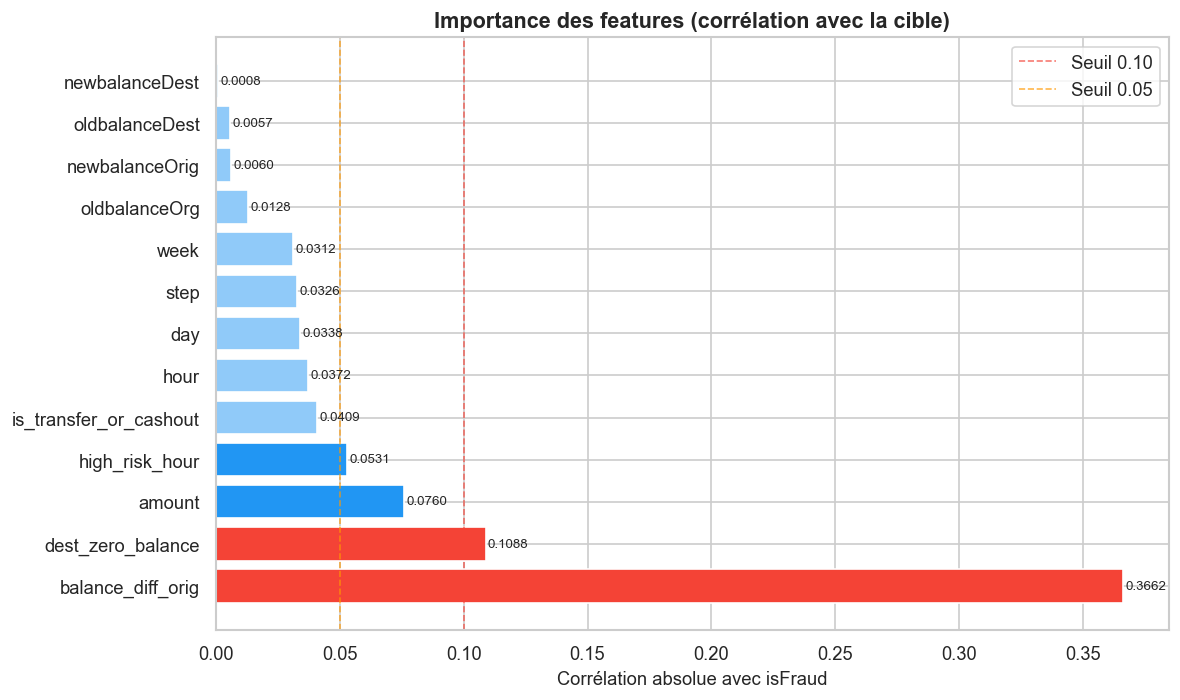

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#F44336" if v > 0.1 else "#2196F3" if v > 0.05 else "#90CAF9"
          for v in correlations_abs.values]
bars = ax.barh(correlations_abs.index, correlations_abs.values, color=colors, edgecolor="white")
ax.set_xlabel("Corrélation absolue avec isFraud")
ax.set_title("Importance des features (corrélation avec la cible)")
ax.axvline(x=0.1, color="#F44336", linestyle="--", alpha=0.7, linewidth=1, label="Seuil 0.10")
ax.axvline(x=0.05, color="#FF9800", linestyle="--", alpha=0.7, linewidth=1, label="Seuil 0.05")
ax.legend()
for bar, val in zip(bars, correlations_abs.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

#### 17. Vérification du Data Leakage

Le data leakage survient quand des features contiennent de l'information
qui ne serait pas disponible au moment de la prédiction en production.
Il faut le détecter ET l'expliquer pour le rapport académique.

In [50]:
# Vérification étendue — toutes colonnes numériques
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
exclude = ["isFraud", "isFlaggedFraud"]
numeric_cols = [c for c in numeric_cols if c not in exclude]

all_corr = df[numeric_cols + ["isFraud"]].corr()["isFraud"].drop("isFraud")
all_corr_abs = all_corr.abs().sort_values(ascending=False)

print("Corrélations absolues avec isFraud — toutes colonnes numériques :")
print(all_corr_abs.round(6).to_string())

# Alerte si corrélation suspecte
high_corr = all_corr_abs[all_corr_abs > 0.5]
print("\n" + "=" * 50)
if len(high_corr) > 0:
    print(f"RISQUE LEAKAGE détecté : {list(high_corr.index)}")
else:
    print("Aucun leakage évident (toutes corrélations < 0.5)")
print("=" * 50)

Corrélations absolues avec isFraud — toutes colonnes numériques :
balance_diff_orig         0.366187
dest_zero_balance         0.108846
amount                    0.076036
high_risk_hour            0.053062
is_transfer_or_cashout    0.040878
hour                      0.037243
day                       0.033824
step                      0.032648
week                      0.031244
oldbalanceOrg             0.012839
newbalanceOrig            0.006000
oldbalanceDest            0.005729
newbalanceDest            0.000772

Aucun leakage évident (toutes corrélations < 0.5)


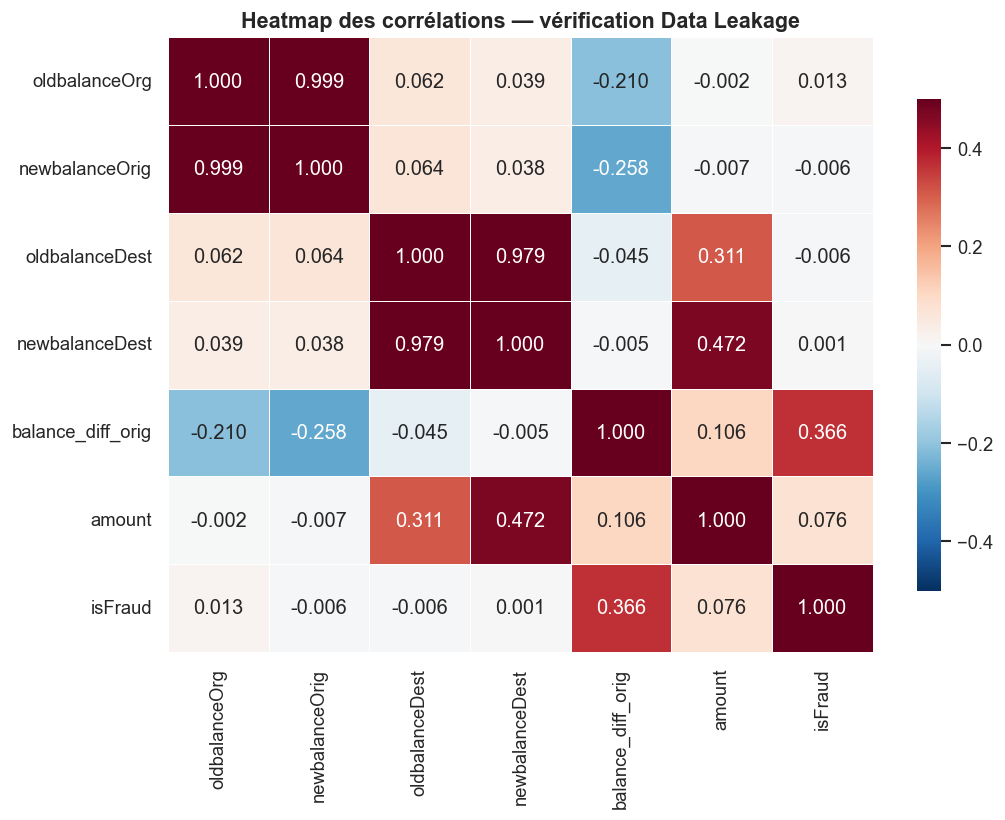

In [51]:
# Heatmap sur les colonnes de balance (vérification originale) + nouvelles features
cols_for_heatmap = [
    "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
    "balance_diff_orig", "amount", "isFraud"
]

correlation_matrix = df[cols_for_heatmap].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    correlation_matrix, annot=True, fmt=".3f", cmap="RdBu_r",
    center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Heatmap des corrélations — vérification Data Leakage", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_leakage_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [52]:
print("""
Conclusion — Data Leakage :

1. Colonnes EXCLUES du modèle (per note Kaggle + justification métier) :
   - oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest
   Raison : Les transactions frauduleuses sont ANNULÉES dans PaySim, donc
   les balances après fraude ne sont pas représentatives de ce qu'on verrait
   en production (le système ne voit pas la balance post-fraude avant détection).

2. Exception — balance_diff_orig (GARDÉE avec précaution) :
   - Représente le comportement (compte vidé ?) plutôt que la valeur absolue.
   - Signal comportemental disponible au moment de la transaction.
   - Corrélation modérée → utile sans créer de leakage fort.

3. Colonnes EXCLUES car non disponibles en production :
   - nameOrig, nameDest : identifiants non encodables directement
   - isFlaggedFraud : résultat d'une règle appliquée simultanément

4. Features RETENUES pour la modélisation :
   amount (+ log1p), step, hour, day, week, high_risk_hour,
   is_transfer_or_cashout, balance_diff_orig, dest_zero_balance
   + type (encodé one-hot)
""")


Conclusion — Data Leakage :

1. Colonnes EXCLUES du modèle (per note Kaggle + justification métier) :
   - oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest
   Raison : Les transactions frauduleuses sont ANNULÉES dans PaySim, donc
   les balances après fraude ne sont pas représentatives de ce qu'on verrait
   en production (le système ne voit pas la balance post-fraude avant détection).

2. Exception — balance_diff_orig (GARDÉE avec précaution) :
   - Représente le comportement (compte vidé ?) plutôt que la valeur absolue.
   - Signal comportemental disponible au moment de la transaction.
   - Corrélation modérée → utile sans créer de leakage fort.

3. Colonnes EXCLUES car non disponibles en production :
   - nameOrig, nameDest : identifiants non encodables directement
   - isFlaggedFraud : résultat d'une règle appliquée simultanément

4. Features RETENUES pour la modélisation :
   amount (+ log1p), step, hour, day, week, high_risk_hour,
   is_transfer_or_cashout, balance_

#### 18. Sauvegarde d’un rapport EDA

In [53]:
# Sauvegarde du rapport EDA complet (JSON + CSV)

eda_report = {
    "dataset": {
        "name": "PaySim Synthetic Financial Fraud Dataset",
        "sample_size": int(len(df)),
        "sampling_method": "stratified_split",
        "random_state": RANDOM_STATE,
        "n_columns": int(df.shape[1]),
    },
    "class_distribution": {
        "fraud_count": int(df["isFraud"].sum()),
        "non_fraud_count": int((df["isFraud"] == 0).sum()),
        "fraud_rate_pct": round(float(df["isFraud"].mean() * 100), 6),
        "imbalance_ratio": round(float(fraud_counts[0] / fraud_counts[1]), 1),
    },
    "baseline_flagged_fraud": {
        "tp": int(tp),
        "fn": int(fn),
        "fp": int(fp),
        "recall": round(float(baseline_recall), 6),
        "precision": round(float(baseline_precision), 6),
        "f1": round(float(baseline_f1), 6),
    },
    "fraud_by_type": fraud_type_detail.to_dict(),
    "temporal": {
        "high_risk_hours": sorted([int(h) for h in high_risk_hours]),
        "fraud_rate_high_risk_pct": round(float(validation.get(1, 0)), 6),
        "fraud_rate_normal_pct": round(float(validation.get(0, 0)), 6),
    },
    "network_analysis": {
        "n_fraud_dest_accounts": int(len(fraud_dest_set)),
        "n_dest_also_cashout": int(len(overlap)),
        "pct_dest_also_cashout": round(len(overlap) / len(fraud_dest_set) * 100, 1),
    },
    "features_engineered": [
        "hour", "day", "week",
        "high_risk_hour",
        "is_transfer_or_cashout",
        "balance_diff_orig",
        "dest_zero_balance",
    ],
    "features_excluded_leakage": [
        "oldbalanceOrg", "newbalanceOrig",
        "oldbalanceDest", "newbalanceDest",
        "nameOrig", "nameDest",
    ],
    "target_metrics": {
        "primary": "Recall",
        "secondary": ["F1-Score", "PR-AUC"],
        "avoid": "Accuracy (trompeuse avec déséquilibre 1:1359)",
        "dl_target_recall_min": round(float(baseline_recall), 4),
    }
}

# Sauvegarder
report_path = REPORTS_DIR / "eda_report.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(eda_report, f, indent=2, ensure_ascii=False)

csv_path = REPORTS_DIR / "eda_summary_stats.csv"
df.describe().round(4).to_csv(csv_path)

corr_path = REPORTS_DIR / "feature_correlations.csv"
all_corr_abs.round(6).to_csv(corr_path, header=["abs_correlation_with_isFraud"])

print("Rapports sauvegardés :")
print(f"  ✅ {report_path}")
print(f"  ✅ {csv_path}")
print(f"  ✅ {corr_path}")
print(f"\nFigures sauvegardées dans : {FIGURES_DIR}")
for fig_file in sorted(FIGURES_DIR.glob("*.png")):
    print(f"  ✅ {fig_file.name}")

Rapports sauvegardés :
  ✅ C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\reports\eda_report.json
  ✅ C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\reports\eda_summary_stats.csv
  ✅ C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\reports\feature_correlations.csv

Figures sauvegardées dans : C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\figures
  ✅ 01_class_imbalance.png
  ✅ 02_transaction_types.png
  ✅ 03_amount_distribution.png
  ✅ 04_fraud_by_amount_quantile.png
  ✅ 05_temporal_analysis.png
  ✅ 06_feature_correlations.png
  ✅ 07_leakage_heatmap.png


---
## Synthèse finale de l'EDA

### Ce qu'on a appris sur le dataset

| Observation | Valeur corrigée | Implication |
|---|---|---|
| Dataset complet | **6 362 620 lignes** (step 1–743, 31 jours) | Couverture temporelle complète |
| Taux de fraude | **0.1291%** dans le sample | Déséquilibre 1:774 → Recall / F1 / PR-AUC |
| Types frauduleux | TRANSFER **(0.77%)** + CASH_OUT **(0.18%)** | `is_transfer_or_cashout` |
| Baseline `isFlaggedFraud` | **Recall = 0.0026**, Precision = 1.0, F1 = 0.0052 | DL doit largement dépasser |
| Limitation baseline | Scope : TRANSFER uniquement, pas CASH_OUT | 67% des fraudes dépassent le seuil mais non flaggées |
| Pattern réseau | Overlap 0.1% dans le sample | `dest_also_cashout` non retenu (batch uniquement) |
| Comptes mules | Balance dest 0/0 : taux fraude **2.46%** | `dest_zero_balance` |
| Temporalité | Heures 0–8 et 21–23 : ratio **7.48×** | `high_risk_hour` |
| `week` | 0–4 (variance > 0 sur dataset complet) | Retenu comme feature |
| `balance_diff_orig` | Corrélation **0.36** avec isFraud | Meilleur signal ; valeurs négatives normales |
| Balances brutes | Corrélation < 0.01 | Exclure (leakage PaySim + note Kaggle) |

### Features retenues pour la modélisation

```
Numériques : amount (log1p), step, hour, day, week, balance_diff_orig
Binaires   : high_risk_hour, is_transfer_or_cashout, dest_zero_balance
Catég.     : type (one-hot encoding → 5 colonnes)
Total      : 14 features après encodage
```

### Prochaine étape — Notebook 02 : Data Preparation
1. Encoder `type` → one-hot (5 colonnes)
2. Appliquer `log1p` sur `amount` → `log_amount`
3. Normaliser les features numériques (`StandardScaler` — fit sur train uniquement)
4. Split stratifié 70% / 15% / 15% avec `SAMPLE_SIZE=200_000`, `RANDOM_STATE=42`
5. Gérer le déséquilibre : `class_weight` + SMOTE sur train uniquement
6. Sauvegarder les datasets et le scaler
